# Encoder input, T = 24, all scenarios: cropped links stored compactly

This notebook turns the prepared files in `src/data/prepared_data/` (written by
`src/pipeline/input_representation.ipynb`) into encoder input for **all 8 scenario folders** (4 Sybil families ×
the 0709 / 1416 groups) and **all classes** (benign, GridSybil, DataReplay, DoSRandom, DoSDisruptive).

**Crop.** A _link_ is everything one receiving car heard from one sender pseudonym, in time order. Each link is cut
into consecutive, **non-overlapping** pieces of at most **24 messages**: a link of 50 messages gives 24 + 24 + 2.
Every message lands in exactly one window and nothing is thrown away. This is the T64 technique with T = 24.

**Compact storage.** Only real rows are stored (no padding on disk), in gzipped JSON shards. Padding to 24 rows and
the mask (1 = real row) are made when a shard is loaded, by `CompactWindowReader` (end of this notebook).

**Duplicated benign traffic (F1).** The 4 families replay the same benign traffic, so every benign window appears
about 4 times (once per family). All copies are kept; each window records its `family` so later code can keep one.

**Very short windows (F11).** DataReplay and DoS attackers change pseudonym every 1–2 messages, so most of their
windows hold 1–3 real rows. They are kept, and their share is reported below.

**Split (RULE 3 change, flagged).** 90 / 10 train / test **by physical vehicle** `"<group>:<vehicle>"`; one
assignment per vehicle across all 4 families. Vehicles in the benign + GridSybil T64 input keep their T64 split
(re-derived here and checked against the T64 files on disk); the other vehicles get a seeded 90 / 10 split,
stratified by (group, "attacker in any family").

**Memory.** Windows are never all held in memory: a counting pass collects counts and the train normalisation sums,
then a writing pass normalises and streams the shards to disk.

In [1]:
from __future__ import annotations

import dataclasses
import gzip
import hashlib
import io
import json
import math
import multiprocessing
import os
import pathlib
import platform
import shutil
import subprocess
import time
from collections.abc import Callable, Iterator
from datetime import datetime, timezone
from typing import Any

import numpy as np
import pandas as pd

# Run from the repository root, so that every relative path resolves the same way every time.
for _folder in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:  # notebooks live in src/<folder>/...
    if (_folder / "CLAUDE.md").is_file():
        os.chdir(_folder)
        break
assert (
    pathlib.Path("CLAUDE.md").is_file() and pathlib.Path("data").is_dir()
), f"run this notebook from the repository root (now in {pathlib.Path.cwd()})"
print("working directory:", pathlib.Path.cwd())

working directory: /Users/bibekgupta/Downloads/projects/sybil-llm


## Settings and the disk guard

Everything that can change lives in one frozen dataclass; it is stored in `metadata.json` next to the output.
The output may only go under `src/data/encoder_input/all/` (never under `data/`, RULE 2). The disk is nearly full,
so `DiskGuard` refuses to write when the projected output is larger than the free space minus 5 GB.

In [2]:
ALL_SCENARIOS: tuple[str, ...] = (
    "DataReplaySybil_0709",
    "DataReplaySybil_1416",
    "DoSDisruptiveSybil_0709",
    "DoSDisruptiveSybil_1416",
    "DoSRandomSybil_0709",
    "DoSRandomSybil_1416",
    "GridSybil_0709",
    "GridSybil_1416",
)


@dataclasses.dataclass(frozen=True)
class EncoderInputSettings:
    """Settings for building the compact T = 24 encoder input.

    Attributes:
        prepared_dir: Folder of prepared files plus `index.json` (read only here).
        out_dir: Where the gzipped shards go (gitignored).
        allowed_out_root: The only folder the writer may write into.
        t64_dir: The benign + GridSybil T64 encoder input whose vehicle split is reused (read only).
        seq_len: Maximum messages per window (T); links are cut into non-overlapping crops of this size.
        scenarios: Scenario folders to read.
        t64_scenarios: Scenario folders the T64 split was drawn from.
        t64_codes: Attack codes the T64 split was drawn from (0 benign, 16 GridSybil).
        test_frac: Share of vehicles per stratum that go to test; the rest is train.
        split_seed: Seed of the vehicle shuffles (the T64 one and the one for the other vehicles).
        short_below: Windows with fewer real rows than this are reported as very short.
        shard_size: Windows per output shard.
        decimals: Decimals kept for every float written to disk.
        gzip_level: Compression level of the shards.
        workers: Number of worker processes for reading.
        files_per_batch: Prepared files handed to the workers at a time (bounds memory in the writing pass).
        size_sample_files: Prepared files per scenario used to estimate the output size.
        disk_margin_gb: Free space that must remain after writing.
        overwrite: Whether an existing output folder may be replaced.
    """

    prepared_dir: str = "src/data/prepared_data"
    out_dir: str = "src/data/encoder_input/all/T24"
    allowed_out_root: str = "src/data/encoder_input/all"
    t64_dir: str = "src/data/encoder_input/benign_gridsybil/T64"
    seq_len: int = 24
    scenarios: tuple[str, ...] = ALL_SCENARIOS
    t64_scenarios: tuple[str, ...] = ("GridSybil_0709", "GridSybil_1416")
    t64_codes: tuple[int, ...] = (0, 16)
    test_frac: float = 0.10
    split_seed: int = 0
    short_below: int = 4
    shard_size: int = 50_000
    decimals: int = 4
    gzip_level: int = 6
    workers: int = 10
    files_per_batch: int = 512
    size_sample_files: int = 24
    disk_margin_gb: float = 5.0
    overwrite: bool = True

    def __post_init__(self) -> None:
        if self.seq_len < 1:
            raise ValueError(f"seq_len must be >= 1, got {self.seq_len}")
        if not set(self.scenarios) <= set(ALL_SCENARIOS) or not self.scenarios:
            raise ValueError(f"unknown scenario folders in {self.scenarios}")
        if not 0.0 < self.test_frac < 1.0:
            raise ValueError(f"test_frac must be in (0, 1), got {self.test_frac}")
        if self.workers < 1 or self.shard_size < 1 or self.files_per_batch < 1:
            raise ValueError("workers, shard_size and files_per_batch must be >= 1")
        out = pathlib.Path(self.out_dir).resolve()
        if out.is_relative_to(pathlib.Path("data").resolve()):
            raise ValueError("out_dir must not be inside data/ (read-only, RULE 2)")
        if not out.is_relative_to(pathlib.Path(self.allowed_out_root).resolve()):
            raise ValueError(f"out_dir {out} is outside the allowed folder {self.allowed_out_root}")


class DiskGuard:
    """Refuses to write when the projected output would leave less than a safety margin of free space."""

    def __init__(self, folder: str | pathlib.Path, margin_gb: float) -> None:
        """Stores the folder whose disk is checked.

        Args:
            folder: Any folder on the target disk (its nearest existing parent is used).
            margin_gb: Free space, in GB, that must remain after writing.
        """
        self.folder = pathlib.Path(folder).resolve()
        self.margin_bytes = int(margin_gb * 1e9)

    def free_bytes(self) -> int:
        """Free bytes on the disk that holds the folder."""
        existing = next(p for p in [self.folder, *self.folder.parents] if p.exists())
        return shutil.disk_usage(existing).free

    def allowance(self) -> int:
        """Bytes that may be written: free space minus the margin."""
        return self.free_bytes() - self.margin_bytes

    def check(self, projected_bytes: float, already_there: int = 0) -> None:
        """Raises if the projected output does not fit.

        Args:
            projected_bytes: Projected size of the output.
            already_there: Bytes of an existing output that will be replaced (freed before writing).
        """
        allowance = self.allowance() + already_there
        if projected_bytes > allowance:
            raise RuntimeError(
                f"projected output {projected_bytes / 1e9:.2f} GB exceeds free space minus "
                f"{self.margin_bytes / 1e9:.0f} GB ({allowance / 1e9:.2f} GB); refusing to write"
            )


def folder_bytes(folder: pathlib.Path) -> int:
    """Total size of the files under a folder (0 if it does not exist)."""
    return sum(p.stat().st_size for p in folder.rglob("*") if p.is_file()) if folder.exists() else 0


SETTINGS = EncoderInputSettings()
FEATURE_NAMES: tuple[str, ...] = (
    "claimed_pos_x",
    "claimed_pos_y",
    "rx_pos_x",
    "rx_pos_y",
    "claimed_vel_x",
    "claimed_vel_y",
    "rx_vel_x",
    "rx_vel_y",
    "claimed_acl_x",
    "claimed_acl_y",
    "range",
    "bearing",
    "log_dtau",
)
N_FEATURES = len(FEATURE_NAMES)
LOG_DTAU_COL = FEATURE_NAMES.index("log_dtau")
GUARD = DiskGuard(SETTINGS.out_dir, SETTINGS.disk_margin_gb)
print(SETTINGS)
print(f"Takeaway: {GUARD.free_bytes() / 1e9:.1f} GB free; the output may use at most {GUARD.allowance() / 1e9:.1f} GB.")

EncoderInputSettings(prepared_dir='src/data/prepared_data', out_dir='src/data/encoder_input/all/T24', allowed_out_root='src/data/encoder_input/all', t64_dir='src/data/encoder_input/benign_gridsybil/T64', seq_len=24, scenarios=('DataReplaySybil_0709', 'DataReplaySybil_1416', 'DoSDisruptiveSybil_0709', 'DoSDisruptiveSybil_1416', 'DoSRandomSybil_0709', 'DoSRandomSybil_1416', 'GridSybil_0709', 'GridSybil_1416'), t64_scenarios=('GridSybil_0709', 'GridSybil_1416'), t64_codes=(0, 16), test_frac=0.1, split_seed=0, short_below=4, shard_size=50000, decimals=4, gzip_level=6, workers=10, files_per_batch=512, size_sample_files=24, disk_margin_gb=5.0, overwrite=True)
Takeaway: 23.9 GB free; the output may use at most 18.9 GB.


## Labels from `index.json` and the 90 / 10 vehicle split

`index.json` holds the attack code of every sender vehicle per scenario folder. The split is by **physical
vehicle** `"<group>:<vehicle>"`: a car keeps one split in every family (the families replay the same traffic, F1).

- **Vehicles of the T64 input** keep their T64 split. The T64 rule is re-derived exactly (seeded shuffle per
  (group, class) over the GridSybil folders, codes 0 / 16, 10% test, seed 0) and compared with the `_info` files
  of the T64 input on disk.
- **All other vehicles** get a seeded (0) 90 / 10 split, stratified by (group, "attacker in any family").

The older four-way split stored in `index.json` is not used.

In [3]:
def group_of(scenario: str) -> str:
    """Returns the time-window group of a scenario folder, e.g. 'GridSybil_0709' -> '0709'."""
    return scenario.rsplit("_", 1)[1]


def family_of(scenario: str) -> str:
    """Returns the attack family of a scenario folder, e.g. 'GridSybil_0709' -> 'GridSybil'."""
    return scenario.rsplit("_", 1)[0]


class IndexBook:
    """Sender labels and per-scenario totals, read from `index.json`.

    Attributes:
        labels: Scenario folder -> {vehicle id -> attack code}.
        class_names: Attack code -> class name.
        counts: Scenario folder -> class name -> {links, messages, ...} as recorded by the input representation.
        normalisation_mean: Mean recorded in the index (used only as a numerical shift and for the size estimate).
        normalisation_std: Standard deviation recorded in the index (size estimate only).
        source: Path and provenance of the index file.
    """

    def __init__(self, index_path: pathlib.Path) -> None:
        """Loads the index.

        Args:
            index_path: Path to `index.json`.
        """
        index = json.loads(index_path.read_text())
        if list(index["features"]) != list(FEATURE_NAMES):
            raise ValueError(f"feature order in {index_path} differs from FEATURE_NAMES")
        self.labels: dict[str, dict[int, int]] = {
            scenario: {int(vehicle): int(code) for vehicle, code in codes.items()}
            for scenario, codes in index["labels"].items()
        }
        self.class_names: dict[int, str] = {int(code): name for code, name in index["class_names"].items()}
        self.counts: dict[str, dict[str, dict[str, int]]] = index["counts"]
        self.normalisation_mean = np.asarray(index["normalisation"]["mean"], dtype=np.float64)
        self.normalisation_std = np.asarray(index["normalisation"]["std"], dtype=np.float64)
        self.source = {"path": str(index_path), "provenance": index.get("provenance", {})}

    def label(self, scenario: str, sender: int) -> int:
        """Returns the sender's attack code, or -1 if it is not known."""
        return self.labels.get(scenario, {}).get(sender, -1)

    def t64_assignment(self, scenarios: tuple[str, ...], codes: tuple[int, ...], test_frac: float, seed: int) -> dict:
        """Re-derives the T64 train / test split exactly (the rule of `encoder_input_T64.ipynb`).

        Returns:
            `{"split_of": {vehicle key -> split}, "per_stratum": {...}}`.
        """
        strata: dict[tuple[str, int], set[str]] = {}
        for scenario in scenarios:
            for vehicle, code in self.labels.get(scenario, {}).items():
                if code in codes:
                    strata.setdefault((group_of(scenario), code), set()).add(f"{group_of(scenario)}:{vehicle}")
        rng = np.random.default_rng(seed)
        split_of: dict[str, str] = {}
        report = {}
        for (group, code), keys in sorted(strata.items()):
            ordered = sorted(keys)
            rng.shuffle(ordered)
            n_test = max(1, int(round(test_frac * len(ordered))))
            for k, key in enumerate(ordered):
                if key in split_of:
                    raise ValueError(f"vehicle {key} is in two strata")  # RULE 3
                split_of[key] = "test" if k < n_test else "train"
            report[f"{group}/{self.class_names.get(code, code)}"] = {"train": len(ordered) - n_test, "test": n_test}
        return {"split_of": split_of, "per_stratum": report}

    def attacker_anywhere(self, scenarios: tuple[str, ...]) -> dict[str, bool]:
        """Every vehicle key with a known label in any of the scenarios -> whether it attacks in any of them."""
        result: dict[str, bool] = {}
        for scenario in scenarios:
            for vehicle, code in self.labels.get(scenario, {}).items():
                if code == -1:
                    continue
                key = f"{group_of(scenario)}:{vehicle}"
                result[key] = result.get(key, False) or code != 0
        return result


class VehicleSplit:
    """The train / test split by physical vehicle: the T64 assignment first, a seeded split for the rest.

    Attributes:
        split_of: Vehicle key `"<group>:<vehicle>"` -> "train" or "test".
        rule_of: Vehicle key -> "t64" or "new".
        report: Rules, per-stratum counts and totals, for the report and metadata.
    """

    SPLITS: tuple[str, ...] = ("train", "test")

    def __init__(self, index: IndexBook, settings: EncoderInputSettings) -> None:
        """Builds the split.

        Args:
            index: Labels lookup.
            settings: The notebook settings.
        """
        s = settings
        t64 = index.t64_assignment(s.t64_scenarios, s.t64_codes, s.test_frac, s.split_seed)
        attacker = index.attacker_anywhere(ALL_SCENARIOS)
        self.split_of: dict[str, str] = dict(t64["split_of"])
        self.rule_of: dict[str, str] = {key: "t64" for key in self.split_of}
        strata: dict[tuple[str, bool], list[str]] = {}
        for key, is_attacker in attacker.items():
            if key not in self.split_of:
                strata.setdefault((key.split(":")[0], is_attacker), []).append(key)
        rng = np.random.default_rng(s.split_seed)
        new_report = {}
        for (group, is_attacker), keys in sorted(strata.items()):
            ordered = sorted(keys)
            rng.shuffle(ordered)
            n_test = max(1, int(round(s.test_frac * len(ordered))))
            for k, key in enumerate(ordered):
                self.split_of[key] = "test" if k < n_test else "train"
                self.rule_of[key] = "new"
            name = f"{group}/{'attacker' if is_attacker else 'never_attacker'}"
            new_report[name] = {"train": len(ordered) - n_test, "test": n_test}
        self.t64_split_of = t64["split_of"]
        self.report = {
            "key": "<group>:<sender vehicle>, one split per physical vehicle across all 4 families",
            "rule_t64": (
                f"vehicles of the benign + GridSybil T64 input keep its split: seeded ({s.split_seed}) shuffle per "
                f"(group, GridSybil-folder class) over {list(s.t64_scenarios)}, codes {list(s.t64_codes)}, "
                f"{s.test_frac:.0%} to test"
            ),
            "rule_new": (
                f"other vehicles: seeded ({s.split_seed}) shuffle per (group, attacker in any family), "
                f"{s.test_frac:.0%} to test"
            ),
            "per_stratum_t64": t64["per_stratum"],
            "per_stratum_new": new_report,
            "vehicles_by_rule": {
                rule: {
                    split: sum(1 for k, r in self.rule_of.items() if r == rule and self.split_of[k] == split)
                    for split in self.SPLITS
                }
                | {"total": sum(1 for r in self.rule_of.values() if r == rule)}
                for rule in ("t64", "new")
            },
            "vehicles": {split: sum(v == split for v in self.split_of.values()) for split in self.SPLITS},
        }

    def split(self, scenario: str, sender: int) -> str | None:
        """Returns the sender vehicle's split, or None if the vehicle has no split."""
        return self.split_of.get(f"{group_of(scenario)}:{sender}")


class T64SplitCheck:
    """Compares the re-derived T64 assignment with the sender splits written in the T64 `_info` files (read only)."""

    def __init__(self, t64_dir: str | pathlib.Path) -> None:
        """Stores the T64 folder.

        Args:
            t64_dir: Root of the T64 encoder input (`<split>/b64/part-*_info.json`).
        """
        self.t64_dir = pathlib.Path(t64_dir)

    def on_disk(self) -> dict[str, str]:
        """Vehicle key -> split, read from every T64 info file; fails if a vehicle is in two splits there."""
        split_of: dict[str, str] = {}
        files = sorted(self.t64_dir.glob("*/b*/part-*_info.json"))
        if not files:
            raise FileNotFoundError(f"no T64 info files under {self.t64_dir}")
        for path in files:
            split = path.parts[-3]
            for row in json.loads(path.read_text())["windows"]:
                key = f"{group_of(row['scenario'])}:{row['sender']}"
                if split_of.setdefault(key, split) != split:
                    raise ValueError(f"T64 vehicle {key} is in two splits on disk")
        return split_of

    def compare(self, derived: dict[str, str]) -> dict[str, int]:
        """Counts agreements; raises if any T64 vehicle on disk gets a different (or no) split here."""
        on_disk = self.on_disk()
        missing = [k for k in on_disk if k not in derived]
        differ = [k for k in on_disk if k in derived and derived[k] != on_disk[k]]
        if missing or differ:
            raise AssertionError(f"T64 split not reproduced: {len(missing)} missing, {len(differ)} differ")
        return {
            "t64_vehicles_on_disk": len(on_disk),
            "t64_vehicles_derived": len(derived),
            "agree": len(on_disk) - len(differ),
            "derived_without_windows_in_t64": len(set(derived) - set(on_disk)),
        }


INDEX = IndexBook(pathlib.Path(SETTINGS.prepared_dir) / "index.json")
SPLIT = VehicleSplit(INDEX, SETTINGS)
T64_CHECK = T64SplitCheck(SETTINGS.t64_dir).compare(SPLIT.t64_split_of)
assert all(SPLIT.split_of[k] == v for k, v in SPLIT.t64_split_of.items())
print(json.dumps(SPLIT.report, indent=1))
print("T64 consistency:", T64_CHECK)
_rules = SPLIT.report["vehicles_by_rule"]
print(
    f"Takeaway: {len(SPLIT.split_of):,} vehicles split ({SPLIT.report['vehicles']}); "
    f"{_rules['t64']['total']:,} keep the T64 split (all {T64_CHECK['agree']:,} T64 vehicles on disk agree), "
    f"{_rules['new']['total']:,} get the new seeded split."
)

{
 "key": "<group>:<sender vehicle>, one split per physical vehicle across all 4 families",
 "rule_t64": "vehicles of the benign + GridSybil T64 input keep its split: seeded (0) shuffle per (group, GridSybil-folder class) over ['GridSybil_0709', 'GridSybil_1416'], codes [0, 16], 10% to test",
 "rule_new": "other vehicles: seeded (0) shuffle per (group, attacker in any family), 10% to test",
 "per_stratum_t64": {
  "0709/Benign": {
   "train": 2561,
   "test": 284
  },
  "0709/GridSybil": {
   "train": 1097,
   "test": 122
  },
  "1416/Benign": {
   "train": 1066,
   "test": 118
  },
  "1416/GridSybil": {
   "train": 456,
   "test": 51
  }
 },
 "per_stratum_new": {
  "0709/never_attacker": {
   "train": 1106,
   "test": 123
  },
  "0709/attacker": {
   "train": 474,
   "test": 53
  }
 },
 "vehicles_by_rule": {
  "t64": {
   "train": 5180,
   "test": 575,
   "total": 5755
  },
  "new": {
   "train": 1580,
   "test": 176,
   "total": 1756
  }
 },
 "vehicles": {
  "train": 6760,
  "test": 

## Reading and cropping the prepared files

There is one prepared file per receiving car. `LinkCropper` reads one file, labels each link by its sender
(links with an unknown label, code -1, are dropped and counted), looks up the sender vehicle's split, and cuts the
link into non-overlapping crops of at most 24 messages. It has two jobs, one per pass over the data:

- `count_file`: counts links, windows (by length), messages, and the train normalisation sums;
- `windows_of_file`: normalises the windows and turns them into the JSON text written to the shards.

`ParallelFiles` runs either job over all files in worker processes (`fork`), a batch of files at a time, so only
one batch of results is ever in memory. The worker functions sit at the top level so the workers can find them.

In [4]:
class TrainNormaliser:
    """Per-feature mean / std from the real rows of the train windows, built from streamed sums.

    The sums are taken around a fixed shift (the mean stored in `index.json`) only to keep the sum of squares
    numerically stable; the shift does not change the result.

    Attributes:
        features: Feature names, in column order.
        shift: Value subtracted before summing, shape (n_features,).
        mean: Per-feature train mean.
        std: Per-feature train standard deviation (1.0 for a constant feature).
        n_values: Per-feature number of train values used (missing log_dtau skipped).
    """

    def __init__(self, features: tuple[str, ...], shift: np.ndarray) -> None:
        self.features = list(features)
        self.shift = np.asarray(shift, dtype=np.float64)
        self.mean: np.ndarray | None = None
        self.std: np.ndarray | None = None
        self.n_values: np.ndarray | None = None

    def fit_from_sums(self, count: np.ndarray, total: np.ndarray, total_sq: np.ndarray) -> TrainNormaliser:
        """Sets mean / std from per-feature count, sum and sum of squares of (value - shift)."""
        if np.any(count == 0):
            raise ValueError("a feature has no train values; cannot fit the normaliser")
        centred_mean = total / count
        variance = np.maximum(total_sq / count - centred_mean**2, 0.0)
        self.n_values = count.astype(np.int64)
        self.mean = self.shift + centred_mean
        std = np.sqrt(variance)
        self.std = np.where(std > 0, std, 1.0)
        return self

    def fit_stand_in(self, mean: np.ndarray, std: np.ndarray) -> TrainNormaliser:
        """Uses given statistics (only for the size estimate, before the train statistics exist)."""
        self.mean, self.std, self.n_values = np.asarray(mean), np.asarray(std), np.zeros(len(self.features), int)
        return self

    def apply(self, x: np.ndarray) -> np.ndarray:
        """Normalises real rows; a missing value (the first log_dtau of a link) becomes 0, the train mean."""
        if self.mean is None:
            raise RuntimeError("fit the normaliser first")
        return np.nan_to_num((x - self.mean) / self.std, nan=0.0)

    def to_dict(self) -> dict[str, Any]:
        """The statistics as plain JSON-ready values."""
        return {
            "features": self.features,
            "mean": [float(v) for v in self.mean],
            "std": [float(v) for v in self.std],
            "n_values": [int(v) for v in self.n_values],
            "fitted_on": "train windows, real rows only (missing first log_dtau of a link skipped)",
            "missing_log_dtau": "first message of each link has no previous message; stored as 0 (= train mean)",
        }


class LinkCropper:
    """Reads one prepared receiver file and turns its links into labelled, split, non-overlapping crops."""

    def __init__(
        self,
        settings: EncoderInputSettings,
        index: IndexBook,
        split: VehicleSplit,
        normaliser: TrainNormaliser | None = None,
    ) -> None:
        """Stores collaborators.

        Args:
            settings: The notebook settings.
            index: Labels lookup.
            split: Vehicle split lookup.
            normaliser: Fitted normaliser; needed only by `windows_of_file`.
        """
        self.settings = settings
        self.index = index
        self.split = split
        self.normaliser = normaliser
        self.root = pathlib.Path(settings.prepared_dir)

    def links(self, path_str: str) -> Iterator[tuple[dict, dict[str, Any]]]:
        """Yields (file facts, link facts) for every link of a file, dropped ones flagged with a reason."""
        record = json.loads(pathlib.Path(path_str).read_text())
        scenario = record["run"].split("/", 1)[0]
        facts = {
            "scenario": scenario,
            "family": family_of(scenario),
            "run": record["run"],
            "receiver_file": str(pathlib.Path(path_str).relative_to(self.root)),
            "receiver": int(record["receiver"]),
        }
        for link in record["links"]:
            sender = int(link["sender"])
            x = np.array(link["x"], dtype=np.float64).reshape(-1, N_FEATURES)  # JSON null -> NaN
            code = self.index.label(scenario, sender)
            split = self.split.split(scenario, sender)
            reason = "empty" if len(x) == 0 else "unknown_label" if code == -1 else "no_split" if split is None else ""
            yield facts, {
                "sender": sender,
                "sender_pseudo": int(link["sender_pseudo"]),
                "x": x,
                "code": code,
                "split": split,
                "drop": reason,
            }

    def count_file(self, path_str: str) -> dict[str, Any]:
        """Counts one file: windows by length, links, messages, drops, train sums and data-quality tallies."""
        t = self.settings.seq_len
        shift = self.index.normalisation_mean
        out: dict[str, Any] = {
            "hist": {},
            "links": {},
            "by_scenario": {},
            "dropped": {},
            "train_count": np.zeros(N_FEATURES),
            "train_sum": np.zeros(N_FEATURES),
            "train_sum_sq": np.zeros(N_FEATURES),
            "nan_real_rows": np.zeros(N_FEATURES, dtype=np.int64),
            "nan_log_dtau_not_first": 0,
            "duplicate_links": 0,
            "vehicles": {},
        }
        seen_links: set[tuple[int, int]] = set()
        for facts, link in self.links(path_str):
            x, n_messages = link["x"], len(link["x"])
            if link["drop"]:
                tally = out["dropped"].setdefault((facts["scenario"], link["drop"]), [0, 0])
                tally[0] += 1
                tally[1] += n_messages
                continue
            link_key = (link["sender_pseudo"], link["sender"])
            out["duplicate_links"] += link_key in seen_links
            seen_links.add(link_key)
            name = self.index.class_names.get(link["code"], str(link["code"]))
            key = (link["split"], facts["family"], name)
            hist = out["hist"].setdefault(key, np.zeros(t + 1, dtype=np.int64))
            hist[t] += n_messages // t
            if n_messages % t:
                hist[n_messages % t] += 1
            out["links"][key] = out["links"].get(key, 0) + 1
            per_scenario = out["by_scenario"].setdefault((facts["scenario"], name), [0, 0])
            per_scenario[0] += 1
            per_scenario[1] += n_messages
            missing = np.isnan(x)
            out["nan_real_rows"] += missing.sum(axis=0)
            out["nan_log_dtau_not_first"] += int(missing[1:, LOG_DTAU_COL].sum())
            out["vehicles"].setdefault(link["split"], set()).add(f"{group_of(facts['scenario'])}:{link['sender']}")
            if link["split"] == "train":
                centred = x - shift
                present = ~missing
                out["train_count"] += present.sum(axis=0)
                out["train_sum"] += np.where(present, centred, 0.0).sum(axis=0)
                out["train_sum_sq"] += np.where(present, centred**2, 0.0).sum(axis=0)
        return out

    def windows_of_file(self, path_str: str) -> dict[str, dict[str, list]]:
        """Normalises and serialises every window of one file, grouped by split.

        Returns:
            split -> {"data": window JSON texts, "info": info JSON texts, "n": real rows per window}.
        """
        t, decimals = self.settings.seq_len, self.settings.decimals
        out: dict[str, dict[str, list]] = {}
        for facts, link in self.links(path_str):
            if link["drop"]:
                continue
            x = np.round(self.normaliser.apply(link["x"]), decimals) + 0.0  # -0.0 -> 0.0
            name = self.index.class_names.get(link["code"], str(link["code"]))
            bucket = out.setdefault(link["split"], {"data": [], "info": [], "n": []})
            for k, start in enumerate(range(0, len(x), t)):
                rows = x[start : start + t]
                n = len(rows)
                window_id = f"{facts['receiver_file']}#{link['sender_pseudo']}-{link['sender']}#{k}"
                bucket["data"].append(
                    f'{{"id":{json.dumps(window_id)},"n":{n},"x":{json.dumps(rows.tolist(), separators=(",", ":"))}}}'
                )
                info = {
                    "id": window_id,
                    "family": facts["family"],
                    "scenario": facts["scenario"],
                    "run": facts["run"],
                    "receiver_file": facts["receiver_file"],
                    "receiver": facts["receiver"],
                    "sender": link["sender"],
                    "sender_pseudo": link["sender_pseudo"],
                    "link_window_index": k,
                    "n_messages": n,
                    "label": link["code"],
                    "label_name": name,
                    "is_attack": int(link["code"] != 0),
                }
                bucket["info"].append(json.dumps(info, separators=(",", ":")))
                bucket["n"].append(n)
        return out


_CROPPER: LinkCropper | None = None  # set by ParallelFiles before the workers fork


def count_worker(path_str: str) -> dict[str, Any]:
    """Worker entry point of the counting pass (must stay top level)."""
    return _CROPPER.count_file(path_str)


def windows_worker(path_str: str) -> dict[str, dict[str, list]]:
    """Worker entry point of the writing pass (must stay top level)."""
    return _CROPPER.windows_of_file(path_str)


class ParallelFiles:
    """Lists the prepared files and runs a worker over them in batches with a fork pool."""

    def __init__(self, settings: EncoderInputSettings) -> None:
        """Stores the settings.

        Args:
            settings: The notebook settings.
        """
        self.settings = settings
        self.root = pathlib.Path(settings.prepared_dir)

    def files(self, scenario: str | None = None) -> list[str]:
        """Prepared files of the chosen scenarios (or one scenario), sorted so the output order is reproducible."""
        found: list[str] = []
        for name in [scenario] if scenario else self.settings.scenarios:
            folder = self.root / name
            if not folder.is_dir():
                raise FileNotFoundError(f"missing scenario folder {folder}")
            found.extend(str(p) for p in sorted(folder.glob("*/traceJSON-*.json")))
        return found

    def run(self, cropper: LinkCropper, worker: Callable[[str], Any], paths: list[str]) -> Iterator[Any]:
        """Yields the worker's result for every path, in order, one batch of files at a time."""
        global _CROPPER
        _CROPPER = cropper
        context = multiprocessing.get_context("fork")
        with context.Pool(self.settings.workers) as pool:
            for start in range(0, len(paths), self.settings.files_per_batch):
                batch = paths[start : start + self.settings.files_per_batch]
                yield from pool.map(worker, batch, chunksize=4)


FILES = ParallelFiles(SETTINGS)
ALL_FILES = FILES.files()
print(f"{len(ALL_FILES):,} prepared files in {len(SETTINGS.scenarios)} scenario folders")

23,032 prepared files in 8 scenario folders


## Size estimate before anything is written

A sample of files per scenario is serialised exactly as the writer will do it (normalised with the statistics
stored in `index.json` as a stand-in, since the train statistics do not exist yet) and gzipped in memory. The
compressed bytes per message are scaled to each scenario's message count from `index.json`. The guard stops here
if the projection does not fit.

In [5]:
class SizeEstimator:
    """Projects the gzipped output size from a sample of serialised files."""

    def __init__(self, settings: EncoderInputSettings, index: IndexBook, files: ParallelFiles) -> None:
        """Stores collaborators.

        Args:
            settings: The notebook settings.
            index: Labels and per-scenario totals.
            files: File lister and parallel runner.
        """
        self.settings = settings
        self.index = index
        self.files = files

    def sample(self, scenario: str) -> list[str]:
        """Evenly spaced files of one scenario."""
        paths = self.files.files(scenario)
        step = max(1, len(paths) // self.settings.size_sample_files)
        return paths[::step][: self.settings.size_sample_files]

    def estimate(self, cropper: LinkCropper) -> pd.DataFrame:
        """Per-scenario sample bytes, sample messages and projected gzipped bytes."""
        rows = []
        for scenario in self.settings.scenarios:
            data, info, messages = [], [], 0
            for result in self.files.run(cropper, windows_worker, self.sample(scenario)):
                for part in result.values():
                    data += part["data"]
                    info += part["info"]
                    messages += sum(part["n"])
            level = self.settings.gzip_level
            sample_bytes = len(gzip.compress(",".join(data).encode(), level)) + len(
                gzip.compress(",".join(info).encode(), level)
            )
            known = sum(v["messages"] for name, v in self.index.counts[scenario].items() if name != "Unknown")
            rows.append(
                {
                    "scenario": scenario,
                    "sample_messages": messages,
                    "sample_windows": len(data),
                    "bytes_per_message": sample_bytes / max(messages, 1),
                    "messages": known,
                    "projected_gb": sample_bytes / max(messages, 1) * known / 1e9,
                }
            )
        return pd.DataFrame(rows).set_index("scenario")


_stand_in = TrainNormaliser(FEATURE_NAMES, INDEX.normalisation_mean).fit_stand_in(
    INDEX.normalisation_mean, INDEX.normalisation_std
)
SIZE = SizeEstimator(SETTINGS, INDEX, FILES).estimate(LinkCropper(SETTINGS, INDEX, SPLIT, _stand_in))
PROJECTED_BYTES = float(SIZE["projected_gb"].sum() * 1e9 * 1.10)  # 10% safety on top of the sample projection
EXISTING_BYTES = folder_bytes(pathlib.Path(SETTINGS.out_dir)) if SETTINGS.overwrite else 0
print(SIZE.round(3).to_string())
GUARD.check(PROJECTED_BYTES, already_there=EXISTING_BYTES)
print(
    f"Takeaway: projected output {PROJECTED_BYTES / 1e9:.2f} GB (incl. 10% safety) fits; "
    f"{(GUARD.allowance() + EXISTING_BYTES) / 1e9:.1f} GB may be written."
)

                         sample_messages  sample_windows  bytes_per_message  messages  projected_gb
scenario                                                                                           
DataReplaySybil_0709               15947            4022             31.023   2954753         0.092
DataReplaySybil_1416                8519            1914             31.232    767958         0.024
DoSDisruptiveSybil_0709            20580            8858             32.262   3822887         0.123
DoSDisruptiveSybil_1416            10814            4533             32.202   1005847         0.032
DoSRandomSybil_0709                20580            8858             36.489   3822887         0.139
DoSRandomSybil_1416                10814            4534             36.645   1005847         0.037
GridSybil_0709                     30404            2267             26.958   5478988         0.148
GridSybil_1416                     15773            1157             27.059   1501368         0.041


## Counting pass: counts and train normalisation statistics

Every file is read once. Nothing is kept per window: only counts per split × family × class (windows by
length, links, messages), the dropped links, and the per-feature count, sum and sum of squares over the real rows
of the **train** windows. The mean and standard deviation come from these train sums only. The per-scenario
link and message totals are compared with `index.json` (all classes except Unknown).

In [6]:
class CountTotals:
    """Adds up the counting-pass results of all files."""

    def __init__(self, seq_len: int) -> None:
        """Starts empty totals.

        Args:
            seq_len: T, the longest window.
        """
        self.seq_len = seq_len
        self.hist: dict[tuple[str, str, str], np.ndarray] = {}
        self.links: dict[tuple[str, str, str], int] = {}
        self.by_scenario: dict[tuple[str, str], list[int]] = {}
        self.dropped: dict[tuple[str, str], list[int]] = {}
        self.train_count = np.zeros(N_FEATURES)
        self.train_sum = np.zeros(N_FEATURES)
        self.train_sum_sq = np.zeros(N_FEATURES)
        self.nan_real_rows = np.zeros(N_FEATURES, dtype=np.int64)
        self.nan_log_dtau_not_first = 0
        self.duplicate_links = 0
        self.vehicles: dict[str, set[str]] = {}
        self.files = 0

    def add(self, result: dict[str, Any]) -> None:
        """Adds one file's counts."""
        self.files += 1
        for key, hist in result["hist"].items():
            self.hist[key] = self.hist.get(key, np.zeros(self.seq_len + 1, dtype=np.int64)) + hist
        for key, value in result["links"].items():
            self.links[key] = self.links.get(key, 0) + value
        for store, part in ((self.by_scenario, result["by_scenario"]), (self.dropped, result["dropped"])):
            for key, (links, messages) in part.items():
                tally = store.setdefault(key, [0, 0])
                tally[0] += links
                tally[1] += messages
        self.train_count += result["train_count"]
        self.train_sum += result["train_sum"]
        self.train_sum_sq += result["train_sum_sq"]
        self.nan_real_rows += result["nan_real_rows"]
        self.nan_log_dtau_not_first += result["nan_log_dtau_not_first"]
        self.duplicate_links += result["duplicate_links"]
        for split, keys in result["vehicles"].items():
            self.vehicles.setdefault(split, set()).update(keys)

    def table(self) -> pd.DataFrame:
        """Links, windows, messages and very short windows per split × family × class."""
        rows = []
        lengths = np.arange(self.seq_len + 1)
        for (split, family, name), hist in sorted(self.hist.items()):
            rows.append(
                {
                    "split": split,
                    "family": family,
                    "class": name,
                    "links": self.links[(split, family, name)],
                    "windows": int(hist.sum()),
                    "messages": int((hist * lengths).sum()),
                    "windows_1_3": int(hist[1 : SETTINGS.short_below].sum()),
                }
            )
        return pd.DataFrame(rows).set_index(["split", "family", "class"])

    def compare_with_index(self, index: IndexBook) -> pd.DataFrame:
        """Links and messages per scenario × class here vs in `index.json`; unknown-label drops vs 'Unknown'."""
        rows = []
        for scenario in SETTINGS.scenarios:
            for name, recorded in index.counts[scenario].items():
                if name == "Unknown":
                    here = self.dropped.get((scenario, "unknown_label"), [0, 0])
                else:
                    here = self.by_scenario.get((scenario, name), [0, 0])
                rows.append(
                    {
                        "scenario": scenario,
                        "class": name,
                        "links": here[0],
                        "links_index": recorded["links"],
                        "messages": here[1],
                        "messages_index": recorded["messages"],
                    }
                )
        table = pd.DataFrame(rows).set_index(["scenario", "class"])
        table["match"] = (table["links"] == table["links_index"]) & (table["messages"] == table["messages_index"])
        return table


_start = time.perf_counter()
COUNTS = CountTotals(SETTINGS.seq_len)
for _result in FILES.run(LinkCropper(SETTINGS, INDEX, SPLIT), count_worker, ALL_FILES):
    COUNTS.add(_result)
NORMALISER = TrainNormaliser(FEATURE_NAMES, INDEX.normalisation_mean).fit_from_sums(
    COUNTS.train_count, COUNTS.train_sum, COUNTS.train_sum_sq
)
INDEX_CHECK = COUNTS.compare_with_index(INDEX)
TABLE = COUNTS.table()
_other_nan = {f: int(n) for f, n in zip(FEATURE_NAMES, COUNTS.nan_real_rows) if n and f != "log_dtau"}
assert not _other_nan, f"missing values outside log_dtau: {_other_nan}"
assert COUNTS.nan_log_dtau_not_first == 0, "a missing log_dtau that is not the first message of its link"
assert COUNTS.duplicate_links == 0, "two links with the same (pseudonym, sender) in one file: window ids would clash"
assert not any(reason == "no_split" for _, reason in COUNTS.dropped), "a labelled vehicle has no split"
assert not set.intersection(*COUNTS.vehicles.values()) if len(COUNTS.vehicles) > 1 else True
assert INDEX_CHECK["match"].all(), INDEX_CHECK[~INDEX_CHECK["match"]]
print(f"counted {COUNTS.files:,} files in {time.perf_counter() - _start:.1f} s")
print(INDEX_CHECK.to_string())
print("dropped:", {f"{s}/{r}": v for (s, r), v in COUNTS.dropped.items()})
print(
    pd.DataFrame(
        {"mean": NORMALISER.mean, "std": NORMALISER.std, "n_values": NORMALISER.n_values}, index=FEATURE_NAMES
    ).round(4)
)
_unknown = sum(v[0] for (s, r), v in COUNTS.dropped.items() if r == "unknown_label")
print(
    f"Takeaway: {int(TABLE['windows'].sum()):,} windows from {int(TABLE['links'].sum()):,} links and "
    f"{int(TABLE['messages'].sum()):,} messages; {_unknown:,} unknown-label links dropped; totals match index.json; "
    f"normalisation from {int(NORMALISER.n_values[0]):,} train rows."
)

counted 23,032 files in 12.1 s
                                              links  links_index  messages  messages_index  match
scenario                class                                                                    
DataReplaySybil_0709    Benign               103860       103860   2081685         2081685   True
                        DataReplaySybil      588828       588828    873068          873068   True
DataReplaySybil_1416    Benign                21658        21658    528518          528518   True
                        DataReplaySybil      143829       143829    239440          239440   True
DoSDisruptiveSybil_0709 Benign               103859       103859   2081446         2081446   True
                        DoSDisruptiveSybil  1547646      1547646   1741441         1741441   True
DoSDisruptiveSybil_1416 Benign                21688        21688    528397          528397   True
                        DoSDisruptiveSybil   381293       381293    477450          477

## Writing pass: normalise and stream the shards

Every file is read a second time. Each window is normalised with the **train** statistics from the counting pass
(the same statistics for every split), rounded to 4 decimals, and appended to its split's buffer; a buffer is
written as soon as it holds 50,000 windows. Layout:

- `<split>/part-XXXXX.json.gz` = `{"seq_len": 24, "features": [...], "windows": [{"id", "n", "x"}]}`, where `x`
  holds only the `n` real rows. **No labels and no vehicle ids.**
- `<split>/part-XXXXX_info.json.gz` = the bookkeeping for the same windows, in the same order (family, scenario,
  run, receiver file, receiver, sender, sender pseudonym, window index in the link, n_messages, label, label name,
  is_attack).

The writer only writes under `src/data/encoder_input/all/`, checks the disk guard before it starts, and stops if
the free space ever drops below the margin.

In [7]:
class ShardedGzipWriter:
    """Streams serialised windows into gzipped JSON shards, one folder per split.

    Attributes:
        out_dir: Output folder (resolved).
        shards: One entry per written shard (split, files, windows, messages, bytes).
    """

    def __init__(self, settings: EncoderInputSettings, features: tuple[str, ...], guard: DiskGuard) -> None:
        """Checks the target folder.

        Args:
            settings: The notebook settings.
            features: Feature names, in column order.
            guard: Disk-space guard.
        """
        self.settings = settings
        self.features = list(features)
        self.guard = guard
        self.out_dir = pathlib.Path(settings.out_dir).resolve()
        root = pathlib.Path(settings.allowed_out_root).resolve()
        if not self.out_dir.is_relative_to(root):
            raise PermissionError(f"Refusing to write to {self.out_dir}: outside the allowed folder {root}.")
        self.buffers: dict[str, dict[str, list]] = {}
        self.numbers: dict[str, int] = {}
        self.shards: list[dict[str, Any]] = []

    def prepare_folder(self, projected_bytes: float) -> None:
        """Checks the guard, then creates the folder (clearing an old output only when overwrite is set)."""
        existing = folder_bytes(self.out_dir)
        if existing and not self.settings.overwrite:
            raise FileExistsError(f"{self.out_dir} is not empty and overwrite is off")
        self.guard.check(projected_bytes, already_there=existing)
        if self.out_dir.exists():
            shutil.rmtree(self.out_dir)
        self.out_dir.mkdir(parents=True)

    def add(self, split: str, part: dict[str, list]) -> None:
        """Appends one file's windows of one split and writes full shards."""
        buffer = self.buffers.setdefault(split, {"data": [], "info": [], "n": []})
        for key in buffer:
            buffer[key].extend(part[key])
        while len(buffer["n"]) >= self.settings.shard_size:
            self._flush(split, self.settings.shard_size)

    def close(self) -> list[dict[str, Any]]:
        """Writes the remaining partial shards and returns the shard list."""
        for split, buffer in self.buffers.items():
            if buffer["n"]:
                self._flush(split, len(buffer["n"]))
        return self.shards

    def _flush(self, split: str, count: int) -> None:
        """Writes the first `count` buffered windows of a split as one shard pair."""
        if self.guard.free_bytes() < self.guard.margin_bytes:
            raise RuntimeError("free disk space fell below the margin; stopping the writer")
        buffer = self.buffers[split]
        data, info, ns = buffer["data"][:count], buffer["info"][:count], buffer["n"][:count]
        for key in buffer:
            del buffer[key][:count]
        number = self.numbers[split] = self.numbers.get(split, -1) + 1
        name = f"part-{number:05d}"
        folder = self.out_dir / split
        folder.mkdir(exist_ok=True)
        head = json.dumps({"seq_len": self.settings.seq_len, "features": self.features}, separators=(",", ":"))
        self._write(folder / f"{name}.json.gz", head[:-1] + ',"windows":[' + ",".join(data) + "]}")
        info_head = json.dumps({"split": split, "shard": name}, separators=(",", ":"))
        self._write(folder / f"{name}_info.json.gz", info_head[:-1] + ',"windows":[' + ",".join(info) + "]}")
        self.shards.append(
            {
                "split": split,
                "file": f"{split}/{name}.json.gz",
                "info": f"{split}/{name}_info.json.gz",
                "windows": len(ns),
                "messages": int(sum(ns)),
                "bytes": (folder / f"{name}.json.gz").stat().st_size + (folder / f"{name}_info.json.gz").stat().st_size,
            }
        )

    def _write(self, path: pathlib.Path, text: str) -> None:
        """Writes gzipped text."""
        with gzip.open(path, "wt", encoding="utf-8", compresslevel=self.settings.gzip_level) as handle:
            handle.write(text)


_start = time.perf_counter()
WRITER = ShardedGzipWriter(SETTINGS, FEATURE_NAMES, GUARD)
WRITER.prepare_folder(PROJECTED_BYTES)
for _result in FILES.run(LinkCropper(SETTINGS, INDEX, SPLIT, NORMALISER), windows_worker, ALL_FILES):
    for _split, _part in _result.items():
        WRITER.add(_split, _part)
SHARDS = WRITER.close()
_shards = pd.DataFrame(SHARDS)
print(f"wrote {len(SHARDS)} shards in {time.perf_counter() - _start:.1f} s")
print(_shards.groupby("split").agg(shards=("file", "size"), windows=("windows", "sum"), messages=("messages", "sum")))
print(
    f"Takeaway: {int(_shards['windows'].sum()):,} windows in {len(SHARDS)} shards, "
    f"{_shards['bytes'].sum() / 1e9:.2f} GB on disk (projected {PROJECTED_BYTES / 1e9:.2f} GB)."
)

wrote 114 shards in 93.6 s
       shards  windows  messages
split                           
test       12   562272   2060592
train     102  5071584  18299943
Takeaway: 5,633,856 windows in 114 shards, 0.62 GB on disk (projected 0.70 GB).


## `metadata.json`

One file that says what is in the folder and how it was made: features, T, layout, settings, the train
normalisation statistics, the split rules with vehicle counts per stratum and per rule, the T64 consistency
result, counts per split × family × class (links, windows, messages, 1–3-row windows), dropped links, the
comparison with `index.json`, size on disk, the shard list, the source and the code / library versions.

In [8]:
class MetadataWriter:
    """Builds and writes metadata.json for the T = 24 encoder input folder."""

    def __init__(self, settings: EncoderInputSettings, features: tuple[str, ...]) -> None:
        """Stores the settings.

        Args:
            settings: The notebook settings.
            features: Feature names, in column order.
        """
        self.settings = settings
        self.features = list(features)

    @staticmethod
    def counts(table: pd.DataFrame) -> dict[str, Any]:
        """Nested split -> family -> class -> {links, windows, messages, windows_1_3}."""
        result: dict[str, Any] = {}
        for (split, family, name), row in table.iterrows():
            result.setdefault(split, {}).setdefault(family, {})[name] = {k: int(v) for k, v in row.items()}
        return result

    @staticmethod
    def provenance() -> dict[str, Any]:
        """Git commit / dirty flag, library versions and a UTC timestamp."""

        def git(*args: str) -> str:
            try:
                return subprocess.run(["git", *args], capture_output=True, text=True, check=True).stdout.strip()
            except (OSError, subprocess.CalledProcessError):
                return ""

        return {
            "git_commit": git("rev-parse", "HEAD") or None,
            "git_dirty": bool(git("status", "--porcelain")),
            "python": platform.python_version(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "platform": platform.platform(),
            "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        }

    def write(self, out_dir: pathlib.Path, **parts: Any) -> dict[str, Any]:
        """Writes metadata.json from the given parts and returns its content."""
        content = {
            "features": self.features,
            "seq_len": self.settings.seq_len,
            "layout": (
                "<split>/part-XXXXX.json.gz = {seq_len, features, windows: [{id, n, x (n real rows x 13)}]} "
                "+ part-XXXXX_info.json.gz (same order); padding to seq_len and the mask (1 = real row) are made "
                "by the loader (CompactWindowReader)"
            ),
            "settings": {
                k: (list(v) if isinstance(v, tuple) else v) for k, v in dataclasses.asdict(self.settings).items()
            },
            **parts,
            "source": {"prepared_dir": self.settings.prepared_dir, "index": INDEX.source},
            "provenance": self.provenance(),
        }
        content["size_on_disk_bytes"] = folder_bytes(out_dir)
        with open(out_dir / "metadata.json", "w") as handle:
            json.dump(content, handle, indent=1)
        return content


_dropped = {f"{s}/{r}": {"links": v[0], "messages": v[1]} for (s, r), v in sorted(COUNTS.dropped.items())}
METADATA = MetadataWriter(SETTINGS, FEATURE_NAMES).write(
    WRITER.out_dir,
    normalisation=NORMALISER.to_dict(),
    split=SPLIT.report | {"t64_consistency": T64_CHECK},
    vehicles_with_windows={split: len(keys) for split, keys in COUNTS.vehicles.items()},
    counts=MetadataWriter.counts(TABLE),
    totals={k: int(v) for k, v in TABLE.sum().items()},
    dropped=_dropped,
    index_comparison=[
        {"scenario": s, "class": c, **{k: (bool(v) if k == "match" else int(v)) for k, v in row.items()}}
        for (s, c), row in INDEX_CHECK.iterrows()
    ],
    size_estimate={"projected_bytes": PROJECTED_BYTES, "per_scenario": SIZE.round(4).reset_index().to_dict("records")},
    shards=SHARDS,
)
print(f"Takeaway: metadata.json written; the folder holds {METADATA['size_on_disk_bytes'] / 1e9:.2f} GB.")

Takeaway: metadata.json written; the folder holds 0.62 GB.


## Windows per split, family and class

Counts from the counting pass (the checks at the end confirm the shards on disk hold exactly these). Benign
windows are listed under every family because each family replays the same benign traffic.

In [9]:
class WindowReport:
    """Summaries of the windows: counts, length distribution, very short windows and benign duplication."""

    def __init__(self, counts: CountTotals, settings: EncoderInputSettings) -> None:
        """Stores the counting-pass totals.

        Args:
            counts: Totals of the counting pass.
            settings: The notebook settings.
        """
        self.counts = counts
        self.settings = settings
        self.table = counts.table()

    def by_split_family_class(self) -> pd.DataFrame:
        """Windows per split × family (rows) and class (columns), with totals."""
        table = self.table["windows"].unstack("class", fill_value=0)
        table["total"] = table.sum(axis=1)
        return table

    def length_share(self) -> pd.DataFrame:
        """Share of each class's windows by number of real rows (1..T)."""
        per_class: dict[str, np.ndarray] = {}
        for (_, _, name), hist in self.counts.hist.items():
            per_class[name] = per_class.get(name, np.zeros(self.settings.seq_len + 1, dtype=np.int64)) + hist
        frame = pd.DataFrame({name: hist[1:] / hist.sum() for name, hist in per_class.items()})
        frame.index = range(1, self.settings.seq_len + 1)
        frame.index.name = "real rows"
        return frame

    def short_share(self) -> pd.DataFrame:
        """Windows and the share with 1–3 real rows, per family × class (both splits together)."""
        grouped = self.table.groupby(["family", "class"])[["windows", "windows_1_3"]].sum()
        grouped["share_1_3"] = (grouped["windows_1_3"] / grouped["windows"]).round(3)
        return grouped

    def benign_duplication(self) -> pd.DataFrame:
        """Benign windows and messages per family; each family is a replay of the same benign traffic (F1)."""
        benign = self.table.xs("Benign", level="class").groupby("family")[["windows", "messages"]].sum()
        return benign


REPORT = WindowReport(COUNTS, SETTINGS)
print(REPORT.by_split_family_class().to_string())
_split_totals = TABLE.groupby("split")["windows"].sum()
print(
    f"Takeaway: train {int(_split_totals.get('train', 0)):,} / test {int(_split_totals.get('test', 0)):,} windows "
    f"({_split_totals.get('test', 0) / _split_totals.sum():.1%} test); benign share "
    f"{TABLE.xs('Benign', level='class')['windows'].sum() / TABLE['windows'].sum():.1%}."
)

class                     Benign  DataReplaySybil  DoSDisruptiveSybil  DoSRandomSybil  GridSybil    total
split family                                                                                             
test  DataReplaySybil      18339            72472                   0               0          0    90811
      DoSDisruptiveSybil   18331                0              191567               0          0   209898
      DoSRandomSybil       18331                0                   0          191570          0   209901
      GridSybil            17164                0                   0               0      34498    51662
train DataReplaySybil     162006           660197                   0               0          0   822203
      DoSDisruptiveSybil  161966                0             1737372               0          0  1899338
      DoSRandomSybil      161966                0                   0         1737411          0  1899377
      GridSybil           163232              

## Window length at T = 24

Share of each class's windows by number of real rows. Full windows (24 rows) come from links longer than 24
messages; the tail of every link gives one shorter window.

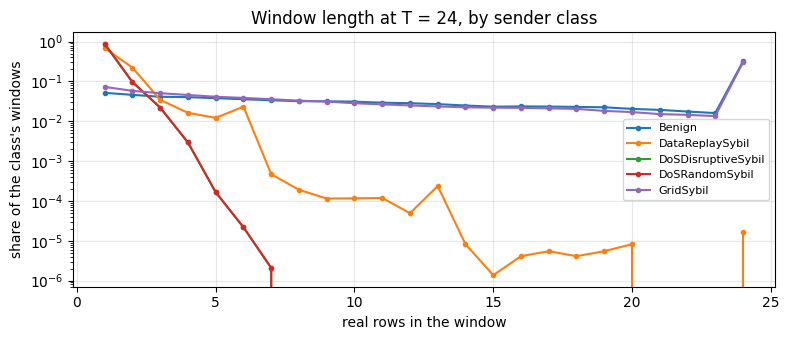

                        1      2      3   4-23     24
Benign              0.052  0.046  0.041  0.542  0.319
DataReplaySybil     0.689  0.223  0.034  0.053  0.000
DoSDisruptiveSybil  0.878  0.097  0.022  0.003  0.000
DoSRandomSybil      0.878  0.097  0.022  0.003  0.000
GridSybil           0.073  0.058  0.051  0.515  0.303
Takeaway: share of full 24-row windows per class: Benign 31.9%, DataReplaySybil 0.0%, DoSDisruptiveSybil 0.0%, DoSRandomSybil 0.0%, GridSybil 30.3%.


In [10]:
import matplotlib.pyplot as plt

_lengths = REPORT.length_share()
_fig, _ax = plt.subplots(figsize=(8, 3.5))
for _name in _lengths.columns:
    _ax.plot(_lengths.index, _lengths[_name], marker="o", ms=3, label=_name)
_ax.set_yscale("log")
_ax.set_xlabel("real rows in the window")
_ax.set_ylabel("share of the class's windows")
_ax.set_title("Window length at T = 24, by sender class")
_ax.grid(alpha=0.3)
_ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
_summary = pd.DataFrame(
    {
        "1": _lengths.loc[1],
        "2": _lengths.loc[2],
        "3": _lengths.loc[3],
        "4-23": _lengths.loc[4:23].sum(),
        "24": _lengths.loc[24],
    }
).round(3)
print(_summary.to_string())
print(
    "Takeaway: share of full 24-row windows per class: "
    + ", ".join(f"{name} {share:.1%}" for name, share in _summary["24"].items())
    + "."
)

## Very short windows (1–3 real rows), per class and family

**F11:** DataReplay and DoS attackers rotate pseudonyms every 1–2 messages, so their links, and therefore their
windows, are mostly 1–3 messages long. Such windows give TimesNet's FFT almost nothing to work with, and the
length alone separates them from benign windows. They are kept here as decided; any later model or probe on
these classes must be read with that in mind (e.g. compare against a length-only baseline).

In [11]:
_short = REPORT.short_share()
print(_short.to_string())
_by_class = _short.groupby("class")[["windows", "windows_1_3"]].sum()
_by_class["share_1_3"] = _by_class["windows_1_3"] / _by_class["windows"]
print(
    "Takeaway (F11): windows with 1–3 real rows: "
    + ", ".join(f"{name} {row.share_1_3:.1%}" for name, row in _by_class.iterrows())
    + "."
)

                                       windows  windows_1_3  share_1_3
family             class                                              
DataReplaySybil    Benign               180345        25156      0.139
                   DataReplaySybil      732669       693674      0.947
DoSDisruptiveSybil Benign               180297        25106      0.139
                   DoSDisruptiveSybil  1928939      1922916      0.997
DoSRandomSybil     Benign               180297        25106      0.139
                   DoSRandomSybil      1928981      1922960      0.997
GridSybil          Benign               180396        25055      0.139
                   GridSybil            321932        58598      0.182
Takeaway (F11): windows with 1–3 real rows: Benign 13.9%, DataReplaySybil 94.7%, DoSDisruptiveSybil 99.7%, DoSRandomSybil 99.7%, GridSybil 18.2%.


## Benign duplication across families

The 4 families replay the same benign traffic (F1), so the benign windows of one family are near-copies of those
in the other three. The factor below is total benign windows / benign windows of the largest family; `family` in
the info files lets later code keep a single copy.

In [12]:
_benign = REPORT.benign_duplication()
print(_benign.to_string())
_factor = _benign["windows"].sum() / _benign["windows"].max()
print(
    f"Takeaway: {int(_benign['windows'].sum()):,} benign windows, {_factor:.2f}x the largest single family "
    f"({_benign['windows'].idxmax()}, {int(_benign['windows'].max()):,})."
)

                    windows  messages
family                               
DataReplaySybil      180345   2610203
DoSDisruptiveSybil   180297   2609843
DoSRandomSybil       180297   2609843
GridSybil            180396   2615943
Takeaway: 721,335 benign windows, 4.00x the largest single family (GridSybil, 180,396).


## Loading a shard: `CompactWindowReader`

Shards store only real rows. The reader loads one shard and returns `x` padded with zero rows to 24, shape
(N, 24, 13), and `mask` (N, 24) with 1 on the real rows. The checks below use it, and training code can reuse it.
The mask must never be given to a classifier as a feature (window length differs by class, see F11).

In [13]:
@dataclasses.dataclass
class CompactShard:
    """One loaded shard.

    Attributes:
        ids: Window ids, in file order.
        x: float32 (N, T, F), zero rows after the real ones.
        mask: uint8 (N, T), 1 on real rows.
        n: int (N,), real rows per window.
    """

    ids: list[str]
    x: np.ndarray
    mask: np.ndarray
    n: np.ndarray


class CompactWindowReader:
    """Loads gzipped compact shards and pads them to T with a mask."""

    def __init__(self, n_features: int = N_FEATURES) -> None:
        """Stores the feature count.

        Args:
            n_features: Features per row.
        """
        self.n_features = n_features

    @staticmethod
    def _json(path: str | pathlib.Path) -> dict[str, Any]:
        """Reads one gzipped JSON file."""
        with gzip.open(path, "rt", encoding="utf-8") as handle:
            return json.load(handle)

    def load(self, path: str | pathlib.Path) -> CompactShard:
        """Loads a data shard into padded arrays plus a mask."""
        data = self._json(path)
        t, windows = int(data["seq_len"]), data["windows"]
        if len(data["features"]) != self.n_features:
            raise ValueError(f"{path}: expected {self.n_features} features, got {len(data['features'])}")
        x = np.zeros((len(windows), t, self.n_features), dtype=np.float32)
        mask = np.zeros((len(windows), t), dtype=np.uint8)
        n = np.zeros(len(windows), dtype=np.int64)
        for i, window in enumerate(windows):
            rows = np.asarray(window["x"], dtype=np.float32).reshape(-1, self.n_features)
            if len(rows) != window["n"] or not 1 <= len(rows) <= t:
                raise ValueError(f"{path}: window {window['id']} has {len(rows)} rows, n = {window['n']}")
            x[i, : len(rows)] = rows
            mask[i, : len(rows)] = 1
            n[i] = len(rows)
        return CompactShard(ids=[w["id"] for w in windows], x=x, mask=mask, n=n)

    def info(self, path: str | pathlib.Path) -> list[dict[str, Any]]:
        """Loads the bookkeeping rows of a shard (its `_info` file)."""
        return self._json(path)["windows"]


READER = CompactWindowReader()
_first = READER.load(WRITER.out_dir / SHARDS[0]["file"])
print(f"{SHARDS[0]['file']}: x {_first.x.shape}, mask {_first.mask.shape}, real rows {int(_first.mask.sum()):,}")
print(f"Takeaway: one shard loads to x {_first.x.shape} + mask {_first.mask.shape}; padding is made at load time.")

train/part-00000.json.gz: x (50000, 24, 13), mask (50000, 24), real rows 198,950
Takeaway: one shard loads to x (50000, 24, 13) + mask (50000, 24); padding is made at load time.


## Checks on the files on disk

Every shard is re-read with `CompactWindowReader` and checked:

- ids match their info rows in order and are unique over all shards (64-bit hashes);
- `n` = number of rows = mask sum = `n_messages`, 1 ≤ n ≤ 24, no missing value, padding rows are zero;
- every kept message is in exactly one window: within a split, each link's windows are consecutive, numbered
  0, 1, 2, …, and all but the last are full (24 rows); totals of links, windows and messages per split × family ×
  class equal the counting pass, and messages equal `index.json` minus the unknown-label links;
- no vehicle `"<group>:<sender>"` is in two splits; every vehicle's split is the one assigned above, and every
  vehicle of the T64 input is in its T64 split;
- the train real rows on disk have mean ≈ 0 and std ≈ 1 (the statistics came from train only);
- round trip: windows from the first shard of each split are rebuilt from the prepared files and must equal what
  the reader returns.

In [14]:
class EncoderInputChecks:
    """Re-reads every shard and checks ids, rows, crops, totals, the split and the normalisation."""

    def __init__(
        self,
        out_dir: pathlib.Path,
        reader: CompactWindowReader,
        split: VehicleSplit,
        t64_on_disk: dict[str, str],
        counts: CountTotals,
        seq_len: int,
    ) -> None:
        """Stores collaborators.

        Args:
            out_dir: Output folder.
            reader: Shard reader.
            split: The vehicle split.
            t64_on_disk: Vehicle key -> split read from the T64 info files.
            counts: Counting-pass totals to compare with.
            seq_len: T.
        """
        self.out_dir = out_dir
        self.reader = reader
        self.split = split
        self.t64_on_disk = t64_on_disk
        self.counts = counts
        self.seq_len = seq_len

    def run(self, shards: list[dict[str, Any]]) -> dict[str, Any]:
        """Runs every check over all shards; returns a short summary."""
        hashes: list[int] = []
        vehicle_splits: dict[str, set[str]] = {}
        totals: dict[tuple[str, str, str], list[int]] = {}
        train_n, train_sum, train_sum_sq = 0, np.zeros(N_FEATURES), np.zeros(N_FEATURES)
        for split in VehicleSplit.SPLITS:
            previous: tuple[str, int, int] | None = None  # (link key, window index, n)
            for entry in [e for e in shards if e["split"] == split]:
                shard = self.reader.load(self.out_dir / entry["file"])
                info = self.reader.info(self.out_dir / entry["info"])
                assert len(info) == len(shard.ids) == entry["windows"], entry["file"]
                assert not np.isnan(shard.x).any(), f"missing value in {entry['file']}"
                assert np.all(shard.x[shard.mask == 0] == 0.0), f"non-zero padding in {entry['file']}"
                assert np.array_equal(shard.mask.sum(axis=1), shard.n), entry["file"]
                if split == "train":
                    real = shard.x[shard.mask == 1].astype(np.float64)
                    train_n += len(real)
                    train_sum += real.sum(axis=0)
                    train_sum_sq += (real**2).sum(axis=0)
                for wid, n, row in zip(shard.ids, shard.n, info):
                    assert wid == row["id"] and n == row["n_messages"] and 1 <= n <= self.seq_len, wid
                    hashes.append(int.from_bytes(hashlib.blake2b(wid.encode(), digest_size=8).digest(), "little"))
                    link = f"{row['receiver_file']}#{row['sender_pseudo']}-{row['sender']}"
                    k = row["link_window_index"]
                    if previous is not None and previous[0] == link:
                        assert k == previous[1] + 1 and previous[2] == self.seq_len, f"broken crop sequence at {wid}"
                    else:
                        assert k == 0, f"link does not start at window 0: {wid}"
                    previous = (link, k, int(n))
                    key = f"{group_of(row['scenario'])}:{row['sender']}"
                    vehicle_splits.setdefault(key, set()).add(split)
                    tally = totals.setdefault((split, row["family"], row["label_name"]), [0, 0, 0])
                    tally[0] += k == 0
                    tally[1] += 1
                    tally[2] += int(n)
        straddling = [v for v, s in vehicle_splits.items() if len(s) > 1]
        assert not straddling, f"vehicles in two splits: {straddling[:5]}"
        wrong = [v for v, s in vehicle_splits.items() if self.split.split_of[v] not in s]
        assert not wrong, f"vehicles not in their assigned split: {wrong[:5]}"
        t64_wrong = [v for v, s in vehicle_splits.items() if v in self.t64_on_disk and {self.t64_on_disk[v]} != s]
        assert not t64_wrong, f"T64 vehicles in a different split: {t64_wrong[:5]}"
        unique = np.unique(np.asarray(hashes, dtype=np.uint64))
        assert len(unique) == len(hashes), f"{len(hashes) - len(unique)} duplicate window ids"
        expected = self.counts.table()
        for key, row in expected.iterrows():
            got = totals.get(key, [0, 0, 0])
            assert got == [row["links"], row["windows"], row["messages"]], (key, got)
        assert len(totals) == len(expected), "a split × family × class group on disk is not in the counting pass"
        mean = train_sum / train_n
        std = np.sqrt(train_sum_sq / train_n - mean**2)
        not_dtau = [i for i in range(N_FEATURES) if i != LOG_DTAU_COL]
        assert np.all(np.abs(mean) < 1e-3) and np.all(np.abs(std[not_dtau] - 1) < 1e-3), (mean, std)
        return {
            "shards": len(shards),
            "windows": len(hashes),
            "messages": int(sum(t[2] for t in totals.values())),
            "links": int(sum(t[0] for t in totals.values())),
            "vehicles": len(vehicle_splits),
            "vehicles_in_two_splits": len(straddling),
            "t64_vehicles_checked": sum(v in self.t64_on_disk for v in vehicle_splits),
            "train_mean_max_abs": float(np.abs(mean).max()),
            "train_std_range": [float(std.min()), float(std.max())],
        }


class RoundTripCheck:
    """Rebuilds windows from the prepared files and compares them with what the reader returns."""

    def __init__(self, cropper: LinkCropper, reader: CompactWindowReader, out_dir: pathlib.Path) -> None:
        """Stores collaborators.

        Args:
            cropper: Cropper with the fitted normaliser.
            reader: Shard reader.
            out_dir: Output folder.
        """
        self.cropper = cropper
        self.reader = reader
        self.out_dir = out_dir

    def run(self, entry: dict[str, Any], n_windows: int, seed: int) -> int:
        """Checks `n_windows` random windows of one shard; returns how many were compared."""
        shard = self.reader.load(self.out_dir / entry["file"])
        rng = np.random.default_rng(seed)
        picked = rng.choice(len(shard.ids), size=min(n_windows, len(shard.ids)), replace=False)
        t = self.cropper.settings.seq_len
        for i in picked:
            receiver_file, link, k = shard.ids[i].split("#")
            pseudo, sender = (int(v) for v in link.split("-"))
            path = str(self.cropper.root / receiver_file)
            match = [
                candidate
                for _, candidate in self.cropper.links(path)
                if (candidate["sender_pseudo"], candidate["sender"]) == (pseudo, sender)
            ]
            assert len(match) == 1, shard.ids[i]
            rows = np.round(self.cropper.normaliser.apply(match[0]["x"]), self.cropper.settings.decimals) + 0.0
            rows = rows[int(k) * t : (int(k) + 1) * t].astype(np.float32)
            n = len(rows)
            assert shard.n[i] == n and np.array_equal(shard.x[i, :n], rows), f"round trip differs for {shard.ids[i]}"
            assert shard.mask[i, :n].all() and not shard.mask[i, n:].any() and not shard.x[i, n:].any()
        return len(picked)


_start = time.perf_counter()
CHECKS = EncoderInputChecks(
    WRITER.out_dir, READER, SPLIT, T64SplitCheck(SETTINGS.t64_dir).on_disk(), COUNTS, SETTINGS.seq_len
).run(SHARDS)
_known_messages = sum(
    v["messages"] for s in SETTINGS.scenarios for name, v in INDEX.counts[s].items() if name != "Unknown"
)
_known_links = sum(v["links"] for s in SETTINGS.scenarios for name, v in INDEX.counts[s].items() if name != "Unknown")
assert CHECKS["messages"] == _known_messages and CHECKS["links"] == _known_links, (CHECKS, _known_messages)
_round_trip = RoundTripCheck(LinkCropper(SETTINGS, INDEX, SPLIT, NORMALISER), READER, WRITER.out_dir)
CHECKS["round_trip_windows"] = sum(
    _round_trip.run(next(e for e in SHARDS if e["split"] == split), 200, seed=SETTINGS.split_seed)
    for split in VehicleSplit.SPLITS
    if any(e["split"] == split for e in SHARDS)
)
print(f"checks ran in {time.perf_counter() - _start:.1f} s")
print("All checks passed:", json.dumps(CHECKS, indent=1))
METADATA["checks"] = CHECKS
(WRITER.out_dir / "metadata.json").write_text(json.dumps(METADATA, indent=1))
print(
    f"Takeaway: all checks pass on {CHECKS['windows']:,} windows / {CHECKS['messages']:,} messages "
    f"(= index.json minus unknown-label links); 0 vehicles in two splits; {CHECKS['t64_vehicles_checked']:,} T64 "
    f"vehicles in their T64 split; {CHECKS['round_trip_windows']} windows round-trip exactly."
)

checks ran in 52.6 s
All checks passed: {
 "shards": 114,
 "windows": 5633856,
 "messages": 20360535,
 "links": 5321386,
 "vehicles": 7508,
 "vehicles_in_two_splits": 0,
 "t64_vehicles_checked": 5752,
 "train_mean_max_abs": 1.6211473250965242e-05,
 "train_std_range": [
  0.8591802109637263,
  1.000000673662843
 ],
 "round_trip_windows": 400
}
Takeaway: all checks pass on 5,633,856 windows / 20,360,535 messages (= index.json minus unknown-label links); 0 vehicles in two splits; 5,752 T64 vehicles in their T64 split; 400 windows round-trip exactly.
